# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Vedika1304-05/flyrank-internship-ml/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

feature_frame rebuilt: 176,738 rows x 7 columns
            client_hash_id           content_hash_id  total_impressions_30d  \
0  client_62f4a7e64f5e0096  content_d0dff76c889de68f                  181.0   
1  client_62f4a7e64f5e0096  content_67741cce996cfafa                   46.0   
2  client_62f4a7e64f5e0096  content_2e6360ad20fd7107                  899.0   
3  client_62f4a7e64f5e0096  content_ac8663da7484669a                   34.0   
4  client_62f4a7e64f5e0096  content_65c50dfe9d87a585                 3108.0   

   total_clicks_30d  ctr_30d  avg_position_30d  days_with_impressions_30d  
0               0.0   0.0000              5.15                         29  
1               1.0   0.0217              4.83                         16  
2               1.0   0.0011              5.15                         31  
3               0.0   0.0000              4.91                         17  
4               0.0   0.0000              6.97                         30  
Distribution summary 

FileNotFoundError: [Errno 2] No such file or directory: 'work/outputs/w04_field_distributions.png'

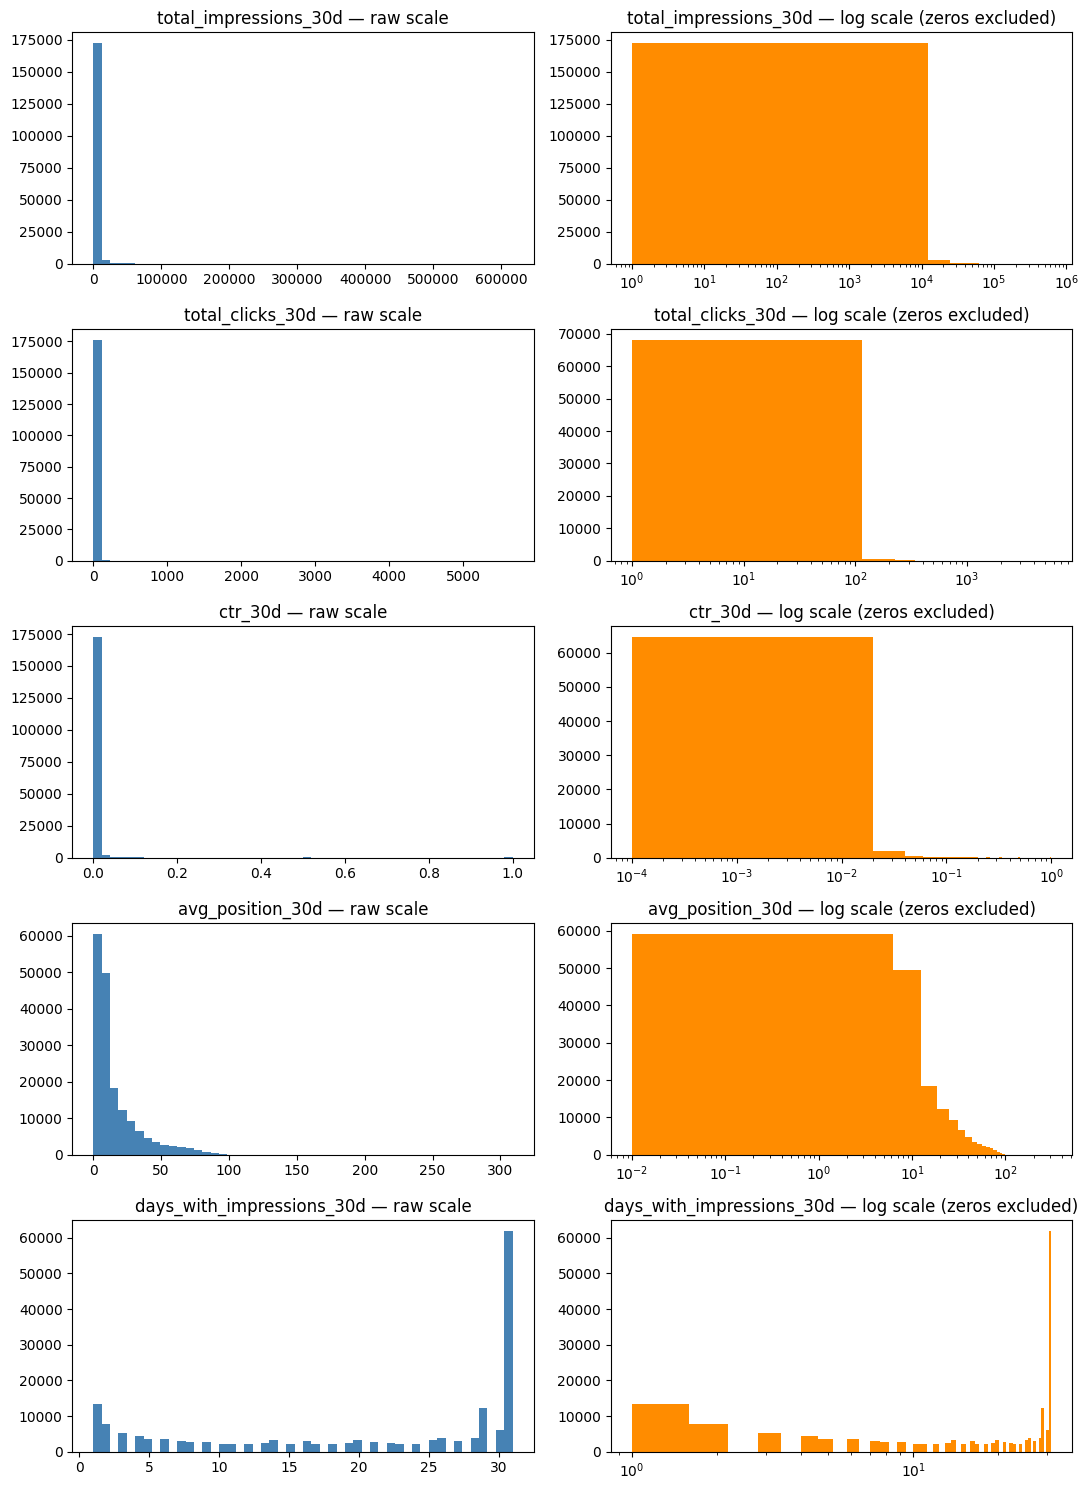

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt
import os, getpass
import duckdb

# --- Auth (same pattern as before — needed fresh in this notebook) ---
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients': f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content': f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':  f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

MONTH_START    = "2026-03-01"
DECISION_POINT = "2026-03-31"

# --- Rebuild feature_frame from scratch ---
feature_frame = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS total_impressions_30d,
        SUM(gsc_clicks) AS total_clicks_30d,
        ROUND(SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0), 4) AS ctr_30d,
        ROUND(AVG(gsc_avg_position), 2) AS avg_position_30d,
        COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS days_with_impressions_30d
    FROM {TABLES['fact_daily']}
    WHERE report_date >= DATE '{MONTH_START}'
      AND report_date <= DATE '{DECISION_POINT}'
    GROUP BY client_hash_id, content_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

print(f"feature_frame rebuilt: {feature_frame.shape[0]:,} rows x {feature_frame.shape[1]} columns")
print(feature_frame.head())

# feature_frame already built in Section 3 of w04/w03 — reuse it here
key_fields = ["total_impressions_30d", "total_clicks_30d", "ctr_30d",
              "avg_position_30d", "days_with_impressions_30d"]

print("="*80)
print("Distribution summary — percentiles + skew, not just mean/std")
print("="*80)
summary = feature_frame[key_fields].describe(percentiles=[.10, .25, .50, .75, .90, .95, .99]).T
summary["skew"] = feature_frame[key_fields].skew()
summary["max_to_p99_ratio"] = feature_frame[key_fields].max() / feature_frame[key_fields].quantile(0.99)
print(summary.round(2))

print("\n" + "="*80)
print("Heavy-tail check: how much does the top 1% dominate vs. the median?")
print("="*80)
for col in key_fields:
    p50 = feature_frame[col].median()
    p99 = feature_frame[col].quantile(0.99)
    ratio = p99 / p50 if p50 != 0 else float("inf")
    print(f"{col:28s} median={p50:>10.2f}  p99={p99:>12.2f}  p99/median ratio={ratio:>8.1f}x")

# --- Visualize: raw histogram vs log-scale histogram, side by side ---
fig, axes = plt.subplots(len(key_fields), 2, figsize=(11, 3 * len(key_fields)))
for i, col in enumerate(key_fields):
    axes[i, 0].hist(feature_frame[col], bins=50, color="steelblue")
    axes[i, 0].set_title(f"{col} — raw scale")

    positive_vals = feature_frame[col][feature_frame[col] > 0]
    axes[i, 1].hist(positive_vals, bins=50, color="darkorange")
    axes[i, 1].set_xscale("log")
    axes[i, 1].set_title(f"{col} — log scale (zeros excluded)")

plt.tight_layout()

plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.